### Cargar librerías

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Cargar datos

In [18]:
df = pd.read_csv("indicadores_rem.csv", sep=";")

#Filtrar por período año 2024
df_2024 = df[df["PERIODO"] == 2024].copy()

In [19]:
# Seleccionar columnas útiles para una primera exploración
columnas_utiles = [
    "CODIGO_ESTABLECIMIENTO",
    "ESTABLECIMIENTO",
    "GLOSA_SSS",
    "AREA_FUNCIONAL",
    "MES",
    "EGRESOS_FALLECIDOS",
    "PROMEDIO_DIAS_ESTADA",
    "NUMERO_EGRESOS",
    "INDICE_OCUPACIONAL",
    "LETALIDAD"
]

df_2024 = df_2024[columnas_utiles]

# Eliminar filas con nulos en variables clave
df_2024 = df_2024.dropna(subset=["PROMEDIO_DIAS_ESTADA", "EGRESOS_FALLECIDOS"])

# Verificar resultado
print(df_2024.head())
print(df_2024.shape)
print(df_2024.info())


        CODIGO_ESTABLECIMIENTO  \
133117                  101100   
133118                  101100   
133119                  101100   
133120                  101100   
133121                  101100   

                                       ESTABLECIMIENTO           GLOSA_SSS  \
133117  Hospital Regional Dr. Juan Noé Crevani (Arica)  Arica y Parinacota   
133118  Hospital Regional Dr. Juan Noé Crevani (Arica)  Arica y Parinacota   
133119  Hospital Regional Dr. Juan Noé Crevani (Arica)  Arica y Parinacota   
133120  Hospital Regional Dr. Juan Noé Crevani (Arica)  Arica y Parinacota   
133121  Hospital Regional Dr. Juan Noé Crevani (Arica)  Arica y Parinacota   

                           AREA_FUNCIONAL  MES  EGRESOS_FALLECIDOS  \
133117  Área Cuidados Intensivos Adultos     1                  11   
133118  Área Cuidados Intensivos Adultos     2                  10   
133119  Área Cuidados Intensivos Adultos     3                   9   
133120  Área Cuidados Intensivos Adultos     4

In [20]:
# Cantidad de filas y columnas
print("Dimensiones:", df_2024.shape)

# Columnas
print("\nColumnas:")
print(df_2024.columns.tolist())

# Tipos de datos
print("\nTipos de datos:")
print(df_2024.dtypes)

# Cantidad de establecimientos distintos
print("\nNúmero de establecimientos:", df_2024["ESTABLECIMIENTO"].nunique())

# Cantidad de áreas funcionales distintas
print("\nNúmero de áreas funcionales:", df_2024["AREA_FUNCIONAL"].nunique())

# Meses presentes
print("\nMeses presentes:")
print(sorted(df_2024["MES"].dropna().unique()))

# Resumen estadístico de variables clave
print("\nResumen estadístico:")
print(df_2024[[
    "PROMEDIO_DIAS_ESTADA",
    "EGRESOS_FALLECIDOS",
    "NUMERO_EGRESOS",
    "INDICE_OCUPACIONAL",
    "LETALIDAD"
]].describe())

# Revisar nulos por columna
print("\nNulos por columna:")
print(df_2024.isna().sum())

# Top 10 establecimientos con más registros
print("\nTop 10 establecimientos con más registros:")
print(df_2024["ESTABLECIMIENTO"].value_counts().head(10))

# Top 10 áreas funcionales con más registros
print("\nTop 10 áreas funcionales con más registros:")
print(df_2024["AREA_FUNCIONAL"].value_counts().head(10))

Dimensiones: (13371, 10)

Columnas:
['CODIGO_ESTABLECIMIENTO', 'ESTABLECIMIENTO', 'GLOSA_SSS', 'AREA_FUNCIONAL', 'MES', 'EGRESOS_FALLECIDOS', 'PROMEDIO_DIAS_ESTADA', 'NUMERO_EGRESOS', 'INDICE_OCUPACIONAL', 'LETALIDAD']

Tipos de datos:
CODIGO_ESTABLECIMIENTO      int64
ESTABLECIMIENTO            object
GLOSA_SSS                  object
AREA_FUNCIONAL             object
MES                         int64
EGRESOS_FALLECIDOS          int64
PROMEDIO_DIAS_ESTADA      float64
NUMERO_EGRESOS              int64
INDICE_OCUPACIONAL        float64
LETALIDAD                 float64
dtype: object

Número de establecimientos: 193

Número de áreas funcionales: 28

Meses presentes:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Resumen estadístico:
       PROMEDIO_DIAS_ESTADA  EGRESOS_FALLECIDOS  NUMERO_EGRESOS  \
count          13371.000000        13371.000000    13371.000000   
mean              19.442067            2.470197       75.364371   
std               90.100424            5.178323      121.685704

In [21]:
# Distribución simple de las variables clave
print("\nValores más altos de PROMEDIO_DIAS_ESTADA:")
print(df_2024["PROMEDIO_DIAS_ESTADA"].sort_values(ascending=False).head(10))

print("\nValores más altos de EGRESOS_FALLECIDOS:")
print(df_2024["EGRESOS_FALLECIDOS"].sort_values(ascending=False).head(10))


Valores más altos de PROMEDIO_DIAS_ESTADA:
136424    3498.00
139164    3461.00
136418    3045.25
136462    2736.00
136704    2536.50
136458    2345.00
136689    2065.80
136691    1894.40
136453    1868.00
136417    1756.50
Name: PROMEDIO_DIAS_ESTADA, dtype: float64

Valores más altos de EGRESOS_FALLECIDOS:
137081    55
138370    51
137082    50
137080    50
133682    47
133678    43
137078    43
136871    40
137083    40
133679    39
Name: EGRESOS_FALLECIDOS, dtype: int64


In [22]:
# Agrupar por establecimiento
df_establecimiento = df_2024.groupby(
    ["CODIGO_ESTABLECIMIENTO", "ESTABLECIMIENTO", "GLOSA_SSS"],
    as_index=False
).agg({
    "EGRESOS_FALLECIDOS": "sum",
    "NUMERO_EGRESOS": "sum",
    "PROMEDIO_DIAS_ESTADA": "mean",
    "INDICE_OCUPACIONAL": "mean"
})

# Recalcular letalidad como porcentaje
df_establecimiento["LETALIDAD_CALCULADA"] = (
    df_establecimiento["EGRESOS_FALLECIDOS"] / df_establecimiento["NUMERO_EGRESOS"]
) * 100

# Redondear para que quede más legible
df_establecimiento["PROMEDIO_DIAS_ESTADA"] = df_establecimiento["PROMEDIO_DIAS_ESTADA"].round(2)
df_establecimiento["INDICE_OCUPACIONAL"] = df_establecimiento["INDICE_OCUPACIONAL"].round(2)
df_establecimiento["LETALIDAD_CALCULADA"] = df_establecimiento["LETALIDAD_CALCULADA"].round(2)

# Ver resultado
#print(df_establecimiento.head())
#print(df_establecimiento.shape)
#print(df_establecimiento.info())
df_establecimiento

,CODIGO_ESTABLECIMIENTO,ESTABLECIMIENTO,GLOSA_SSS,EGRESOS_FALLECIDOS,NUMERO_EGRESOS,PROMEDIO_DIAS_ESTADA,INDICE_OCUPACIONAL,LETALIDAD_CALCULADA
0,101100,Hospital Regional Dr. Juan Noé Crevani (Arica),Arica y Parinacota,423,16738,7.00,67.27,2.53
1,102100,Hospital Dr. Ernesto Torres Galdames (Iquique),Tarapacá,357,17726,8.56,75.15,2.01
2,103100,Hospital Dr. Leonardo Guzmán (Antofagasta),Antofagasta,752,20056,26.84,74.25,3.75
3,103101,Hospital Dr. Carlos Cisternas (Calama),Antofagasta,257,9641,11.28,53.30,2.67
4,103102,Hospital Dr. Marcos Macuada (Tocopilla),Antofagasta,41,994,5.73,44.54,4.12
...,...,...,...,...,...,...,...,...
188,133160,Hospital Comunitario de Achao,Chiloé,23,560,5.29,33.65,4.11
189,133165,Hospital de Quellón,Chiloé,28,1907,4.06,61.09,1.47
190,133170,Hospital Comunitario de Queilén,Chiloé,4,83,9.95,74.38,4.82
191,200717,Complejo Asistencial Padre las Casas,Araucanía Sur,242,6389,21.82,78.72,3.79


### Estadía vs Egresos fallecidos

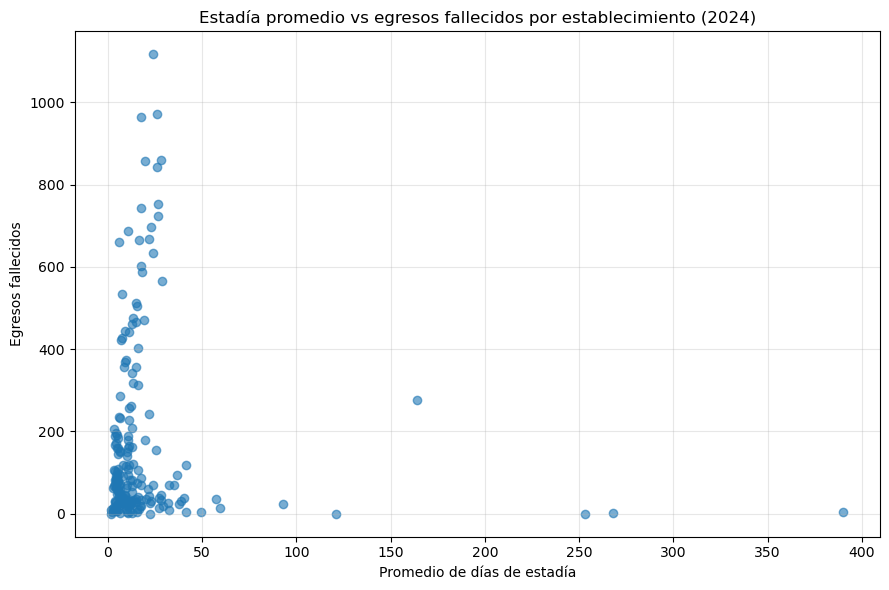

In [23]:
plt.figure(figsize=(9, 6))
plt.scatter(
    df_establecimiento["PROMEDIO_DIAS_ESTADA"],
    df_establecimiento["EGRESOS_FALLECIDOS"],
    alpha=0.6
)

plt.xlabel("Promedio de días de estadía")
plt.ylabel("Egresos fallecidos")
plt.title("Estadía promedio vs egresos fallecidos por establecimiento (2024)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

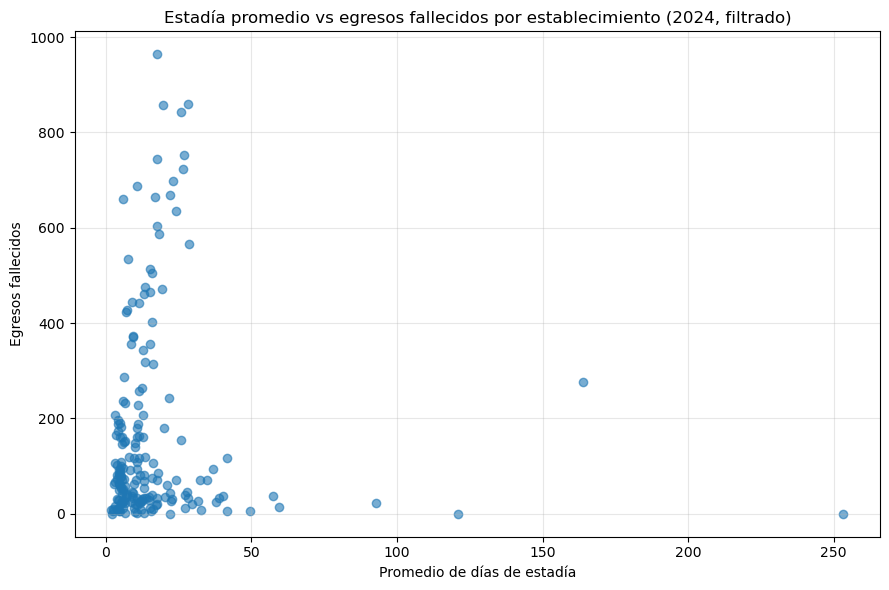

In [24]:
df_plot_1 = df_establecimiento[
    (df_establecimiento["PROMEDIO_DIAS_ESTADA"] <= df_establecimiento["PROMEDIO_DIAS_ESTADA"].quantile(0.99)) &
    (df_establecimiento["EGRESOS_FALLECIDOS"] <= df_establecimiento["EGRESOS_FALLECIDOS"].quantile(0.99))
]

plt.figure(figsize=(9, 6))
plt.scatter(
    df_plot_1["PROMEDIO_DIAS_ESTADA"],
    df_plot_1["EGRESOS_FALLECIDOS"],
    alpha=0.6
)

plt.xlabel("Promedio de días de estadía")
plt.ylabel("Egresos fallecidos")
plt.title("Estadía promedio vs egresos fallecidos por establecimiento (2024, filtrado)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Índice ocupacional vs Egresos fallecidos

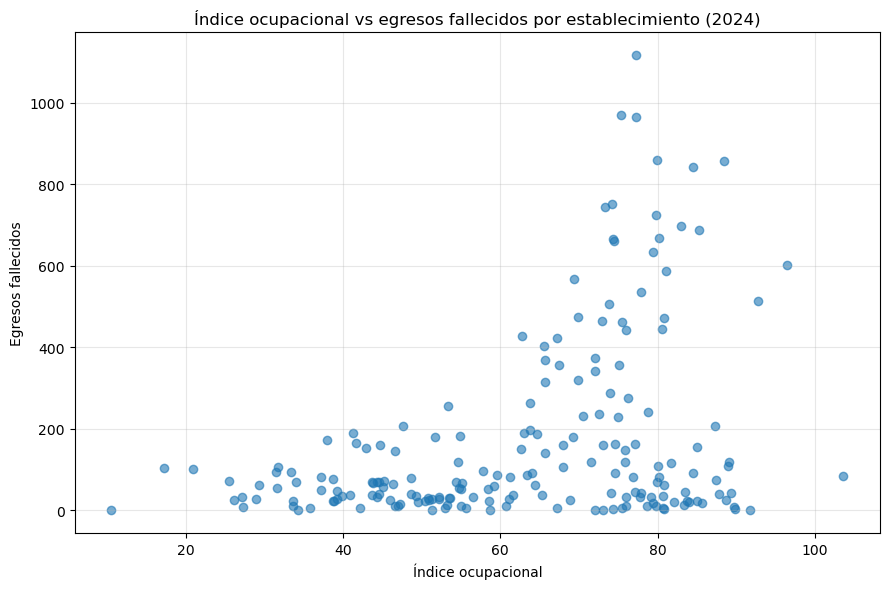

In [25]:
plt.figure(figsize=(9, 6))
plt.scatter(
    df_establecimiento["INDICE_OCUPACIONAL"],
    df_establecimiento["EGRESOS_FALLECIDOS"],
    alpha=0.6
)

plt.xlabel("Índice ocupacional")
plt.ylabel("Egresos fallecidos")
plt.title("Índice ocupacional vs egresos fallecidos por establecimiento (2024)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

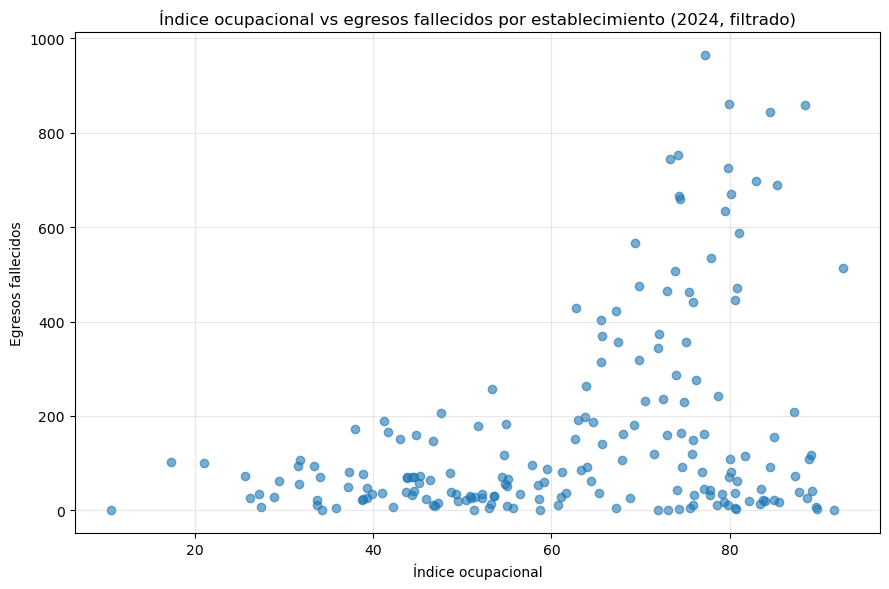

In [26]:
df_plot_2 = df_establecimiento[
    (df_establecimiento["INDICE_OCUPACIONAL"] <= df_establecimiento["INDICE_OCUPACIONAL"].quantile(0.99)) &
    (df_establecimiento["EGRESOS_FALLECIDOS"] <= df_establecimiento["EGRESOS_FALLECIDOS"].quantile(0.99))
]

plt.figure(figsize=(9, 6))
plt.scatter(
    df_plot_2["INDICE_OCUPACIONAL"],
    df_plot_2["EGRESOS_FALLECIDOS"],
    alpha=0.6
)

plt.xlabel("Índice ocupacional")
plt.ylabel("Egresos fallecidos")
plt.title("Índice ocupacional vs egresos fallecidos por establecimiento (2024, filtrado)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A medida que aumeta el índice ocupacional (mayor saturación) aparece más establecimientos con mayor cantidad de egresos fallecidos, lo que apunta a una correlación

In [27]:
# Crear categorías de ocupación
df_establecimiento["GRUPO_OCUPACION"] = pd.cut(
    df_establecimiento["INDICE_OCUPACIONAL"],
    bins=[0, 50, 75, 100],
    labels=["Baja", "Media", "Alta"],
    include_lowest=True
)

In [28]:
# Revisar cuántos establecimientos hay en cada grupo
print(df_establecimiento["GRUPO_OCUPACION"].value_counts(dropna=False))

# Ver algunas filas
print(df_establecimiento[[
    "ESTABLECIMIENTO",
    "INDICE_OCUPACIONAL",
    "GRUPO_OCUPACION",
    "EGRESOS_FALLECIDOS"
]].head(10))

Media    76
Alta     63
Baja     53
NaN       1
Name: GRUPO_OCUPACION, dtype: int64
                                     ESTABLECIMIENTO  INDICE_OCUPACIONAL  \
0     Hospital Regional Dr. Juan Noé Crevani (Arica)               67.27   
1     Hospital Dr. Ernesto Torres Galdames (Iquique)               75.15   
2         Hospital Dr. Leonardo Guzmán (Antofagasta)               74.25   
3             Hospital Dr. Carlos Cisternas (Calama)               53.30   
4            Hospital Dr. Marcos Macuada (Tocopilla)               44.54   
5                       Hospital 21 de Mayo (Taltal)               33.69   
6                             Hospital de Mejillones               60.72   
7             Hospital San José del Carmen (Copiapó)               67.50   
8  Hospital Dr. Jerónimo Méndez Arancibia (Chañaral)               27.11   
9  Hospital Provincial del Huasco Monseñor Fernan...               67.98   

  GRUPO_OCUPACION  EGRESOS_FALLECIDOS  
0           Media                 423  

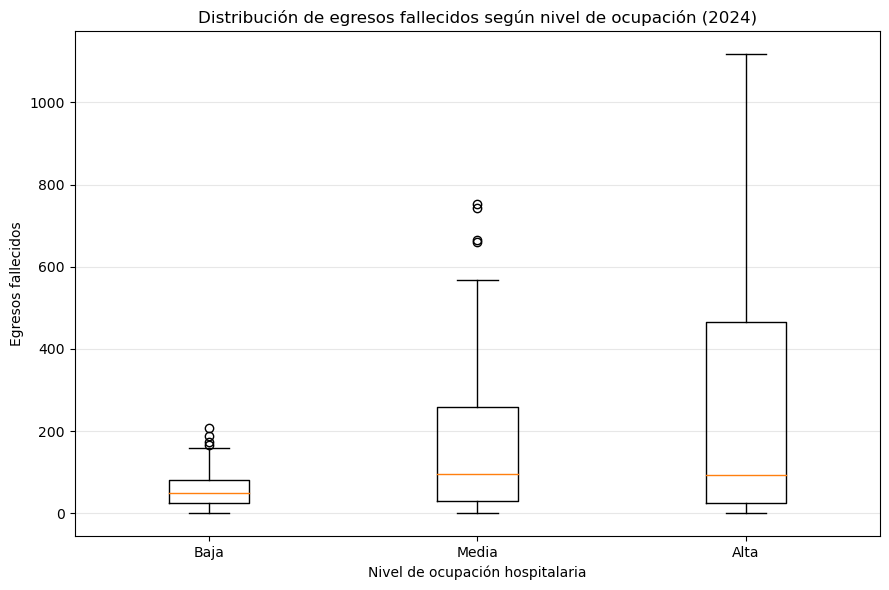

In [29]:
# Preparar datos por grupo
datos_boxplot = [
    df_establecimiento[df_establecimiento["GRUPO_OCUPACION"] == "Baja"]["EGRESOS_FALLECIDOS"],
    df_establecimiento[df_establecimiento["GRUPO_OCUPACION"] == "Media"]["EGRESOS_FALLECIDOS"],
    df_establecimiento[df_establecimiento["GRUPO_OCUPACION"] == "Alta"]["EGRESOS_FALLECIDOS"]
]

plt.figure(figsize=(9, 6))
plt.boxplot(datos_boxplot, labels=["Baja", "Media", "Alta"])

plt.xlabel("Nivel de ocupación hospitalaria")
plt.ylabel("Egresos fallecidos")
plt.title("Distribución de egresos fallecidos según nivel de ocupación (2024)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

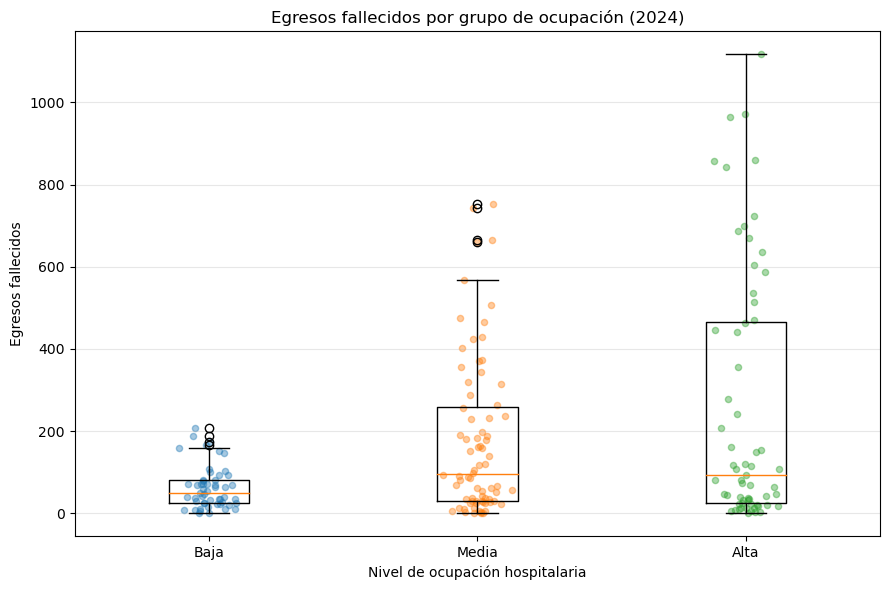

In [30]:
plt.figure(figsize=(9, 6))

grupos = ["Baja", "Media", "Alta"]
datos = []

for g in grupos:
    valores = df_establecimiento[df_establecimiento["GRUPO_OCUPACION"] == g]["EGRESOS_FALLECIDOS"]
    datos.append(valores)

plt.boxplot(datos, labels=grupos)

# Agregar puntos con pequeño desplazamiento horizontal
for i, g in enumerate(grupos, start=1):
    y = df_establecimiento[df_establecimiento["GRUPO_OCUPACION"] == g]["EGRESOS_FALLECIDOS"]
    x = np.random.normal(i, 0.05, size=len(y))
    plt.scatter(x, y, alpha=0.4, s=20)

plt.xlabel("Nivel de ocupación hospitalaria")
plt.ylabel("Egresos fallecidos")
plt.title("Egresos fallecidos por grupo de ocupación (2024)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Ejemplo de como quedarí en Boxplot con puntos